In [3]:
KEY=("projects/j8005-metabatt/Metabatt/VTC/METABatt_Sony_Murata_18650VTC6_008/"
     "J8005_BMWK_METABatt=METABatt_Sony_Murata_18650VTC6_008=2024-09-09_105924="
     "jri_Aging_VTC6_Cyc_25grad_10SOC_20DOD_05C=TS012322 _ Format01="
     "Kreis M3-009=filesize-131081191=finished.parquet")

with fs.open(KEY) as fh:
    pf=pq.ParquetFile(fh)
    print(pf.schema_arrow)
    d=pf.read(columns=['Zeit','Spannung','Strom','Prozedur']).to_pandas()

print(d['Prozedur'].value_counts())
print(f"\nI range: {d['Strom'].min():.2f} ~ {d['Strom'].max():.2f} A")
print(f"V range: {d['Spannung'].min():.3f} ~ {d['Spannung'].max():.3f} V")

Zeit: timestamp[ms, tz=UTC]
Spannung: double
Strom: double
T1: double
Prozedur: string
Zustand: string
AhAkku: double
Ahjo_Test_ID: int64
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 1006
Prozedur
jri_Aging_VTC6_Cyc_25grad_10SOC_20DOD_05C    2896054
jri_Discharge_C2                                9240
jri_TempCriterion_25                             604
Name: count, dtype: int64

I range: -1.44 ~ 1.50 A
V range: 2.499 ~ 4.200 V


C:\Users\zho-xli\AppData\Local\Temp\ipykernel_7116\1478750544.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  q=np.trapz(np.abs(I[s:e]),t)/3600.0


371 discharge segs; top-8 Q [Ah]: [1.46  0.591 0.579 0.579 0.579 0.579 0.579 0.579]
Q直方分布: >2.5Ah有0段(CU满放?), 0.4~0.8Ah有370段(20%DOD老化?)
最深放电 Q=1.460Ah, 段内Prozedur=jri_Discharge_C2, IC主峰@3.464V


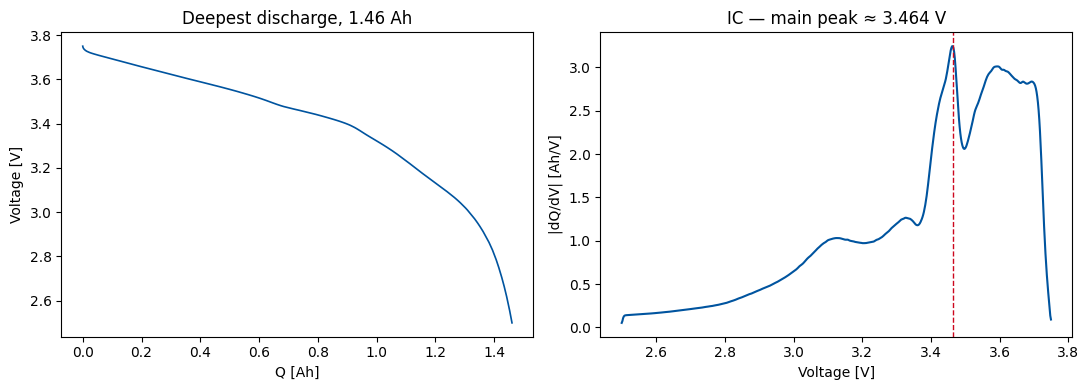

In [5]:
d['Zeit']=TS(d['Zeit'])
I=d['Strom'].values; V=d['Spannung'].values

I_thresh=0.2                      # 先宽松抓所有放电,靠容量排序区分CU满放和20%DOD老化脉冲
is_dch=I<-I_thresh
diff=np.diff(is_dch.astype(int))
starts=np.where(diff==1)[0]+1; ends=np.where(diff==-1)[0]+1
if is_dch[0]: starts=np.r_[0,starts]
if is_dch[-1]: ends=np.r_[ends,len(d)]
segs=[(s,e) for s,e in zip(starts,ends) if e-s>=MIN_SEG]

cap_list=[]
for (s,e) in segs:
    t=(d['Zeit'].iloc[s:e]-d['Zeit'].iloc[s]).dt.total_seconds().values
    q=np.trapz(np.abs(I[s:e]),t)/3600.0
    cap_list.append(q)
cap_arr=np.array(cap_list)
print(f"{len(segs)} discharge segs; top-8 Q [Ah]:", np.round(np.sort(cap_arr)[::-1][:8],3))
print(f"Q直方分布: >2.5Ah有{(cap_arr>2.5).sum()}段(CU满放?), 0.4~0.8Ah有{((cap_arr>0.4)&(cap_arr<0.8)).sum()}段(20%DOD老化?)")

# 取最深放电段 → check-up 满放
s,e=segs[int(cap_arr.argmax())]
seg=d.iloc[s:e]
t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
Vs=seg['Spannung'].values; Is=seg['Strom'].values
Q=np.cumsum(np.abs(Is)*np.diff(t,prepend=t[0])/3600.0)

o=np.argsort(Vs); Vu,idx=np.unique(Vs[o],return_index=True); Qu=Q[o][idx]
vgrid=np.arange(Vu.min(),Vu.max(),DV_GRID)
Qsm=gaussian_filter1d(np.interp(vgrid,Vu,Qu),sigma=SIGMA)
IC=np.abs(np.gradient(Qsm,vgrid))
ip=IC.argmax(); Vpeak=vgrid[ip]
print(f"最深放电 Q={cap_arr.max():.3f}Ah, 段内Prozedur={seg['Prozedur'].iloc[0]}, IC主峰@{Vpeak:.3f}V")

import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(Q,Vs,lw=1.2,color='#00549F')
ax[0].set_xlabel('Q [Ah]'); ax[0].set_ylabel('Voltage [V]'); ax[0].set_title(f'Deepest discharge, {cap_arr.max():.2f} Ah')
ax[1].plot(vgrid,IC,lw=1.5,color='#00549F')
ax[1].axvline(Vpeak,ls='--',color='#CC071E',lw=1)
ax[1].set_xlabel('Voltage [V]'); ax[1].set_ylabel('|dQ/dV| [Ah/V]'); ax[1].set_title(f'IC — main peak ≈ {Vpeak:.3f} V')
plt.tight_layout(); plt.show()

66 parquet files
797 full discharges, capacity 2.00~3.02 Ah (SOH按3.0Ah: 67%~101%)


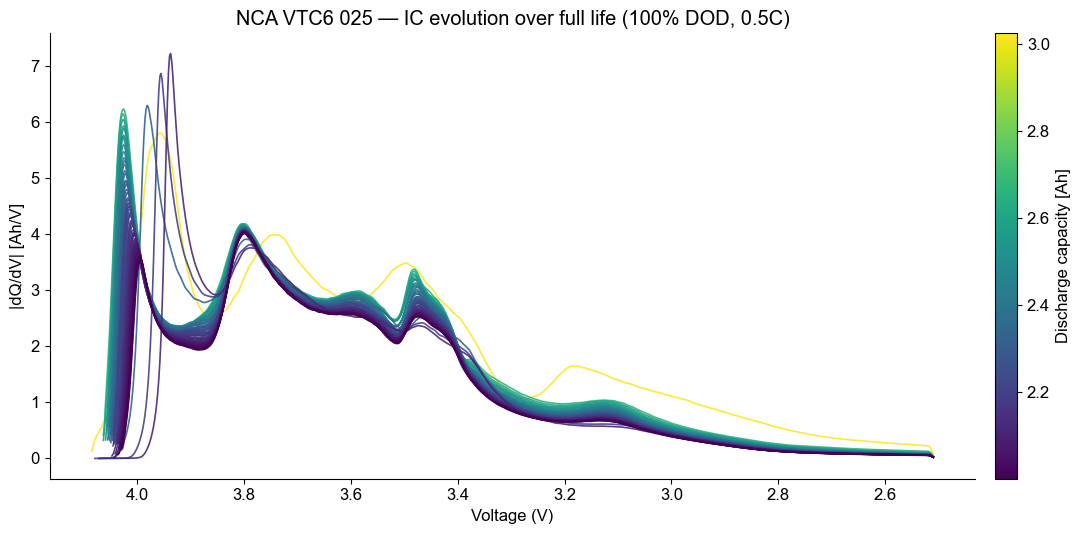

~3.45V (graphite?): 峰高~容量 相关 r=0.974
~3.6V: 峰高~容量 相关 r=0.848
~3.8V (NCA?): 峰高~容量 相关 r=0.450


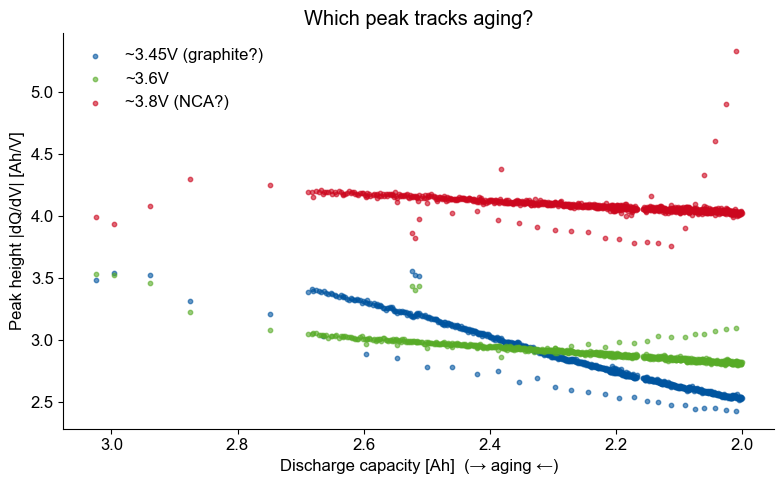

In [ ]:
# ================================================================
# NCA VTC6 025: 全生命周期 IC 演化 + 逐峰高度追踪
# 目的: 找出哪个峰随老化单调变化 → 定NCA侧锚点
# 前提: fs, OPTS, TS 已定义
# ================================================================
import numpy as np, pandas as pd, pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter1d

DV_GRID=0.002; SIGMA=2; MIN_SEG=10
BASE="projects/j8005-metabatt/Metabatt/VTC/METABatt_Sony_Murata_18650VTC6_025"

files=[f for f in sorted(fs.ls(BASE)) if f.endswith('.parquet')]
print(f"{len(files)} parquet files")

curves=[]     # (cap_Ah, vgrid, IC)
for f in files:
    with fs.open(f) as fh:
        d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
    d['Zeit']=TS(d['Zeit'])
    I=d['Strom'].values
    m=I<-1.0
    diff=np.diff(m.astype(int))
    st=np.where(diff==1)[0]+1; en=np.where(diff==-1)[0]+1
    if m[0]: st=np.r_[0,st]
    if m[-1]: en=np.r_[en,len(d)]
    for s,e in zip(st,en):
        if e-s<MIN_SEG: continue
        seg=d.iloc[s:e]
        V=seg['Spannung'].values
        i0=np.argmax(V<V[0]-0.015)                    # 掐起始IR瞬态
        if i0>0 and e-s-i0>=MIN_SEG:
            seg=seg.iloc[i0:]; V=seg['Spannung'].values
        t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
        Q=np.cumsum(np.abs(seg['Strom'].values)*np.diff(t,prepend=t[0])/3600.0)
        if Q[-1]<2.0: continue                        # 对025 dod100成立 其他dod会受影响所以要调整
        o=np.argsort(V); Vu,idx=np.unique(V[o],return_index=True); Qu=Q[o][idx]
        vgrid=np.arange(Vu.min()+0.01,Vu.max()-0.01,DV_GRID)
        if len(vgrid)<50: continue
        Qsm=gaussian_filter1d(np.interp(vgrid,Vu,Qu),sigma=SIGMA)
        curves.append((Q[-1], vgrid, np.abs(np.gradient(Qsm,vgrid))))

curves.sort(key=lambda c:-c[0])                       # 新→旧
caps=np.array([c[0] for c in curves])
print(f"{len(curves)} full discharges, capacity {caps.min():.2f}~{caps.max():.2f} Ah "
      f"(SOH按3.0Ah: {caps.min()/3*100:.0f}%~{caps.max()/3*100:.0f}%)")

norm=Normalize(caps.min(),caps.max()); cmap=cm.viridis
plt.rcParams.update({'font.size':12,'font.family':'Arial'})

# ============ 图1: 全寿命IC叠加 ============
N_SHOW=60
idx=np.linspace(0,len(curves)-1,min(N_SHOW,len(curves))).astype(int)
fig,ax=plt.subplots(figsize=(11,5.5))
for i in idx:
    cap_i,vgrid,IC=curves[i]
    ax.plot(vgrid,IC,color=cmap(norm(cap_i)),lw=1.2,alpha=0.9)
ax.set_xlabel('Voltage (V)'); ax.set_ylabel('|dQ/dV| [Ah/V]')
ax.set_title('NCA VTC6 025 — IC evolution over full life (100% DOD, 0.5C)')
ax.invert_xaxis()
sm=cm.ScalarMappable(norm=norm,cmap=cmap); sm.set_array([])
fig.colorbar(sm,ax=ax,fraction=0.035,pad=0.02).set_label('Discharge capacity [Ah]')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('nca025_ic_lifetime.png',dpi=200,bbox_inches='tight')
plt.show()

# ============ 图2: 逐峰高度 vs 容量 ============
# 候选峰区间(按你上次单循环图的峰位设定, 可按图1微调)
PEAK_BANDS={'~3.45V (graphite?)':(3.35,3.55),
            '~3.6V':(3.55,3.70),
            '~3.8V (NCA?)':(3.72,3.90)}
fig,ax=plt.subplots(figsize=(8,5))
colors=['#00549F','#57AB27','#CC071E']
for (name,(lo,hi)),c in zip(PEAK_BANDS.items(),colors):
    hs=[]
    for cap_i,vgrid,IC in curves:
        m=(vgrid>=lo)&(vgrid<=hi)
        hs.append(IC[m].max() if m.sum()>5 else np.nan)
    ax.scatter(caps,hs,s=10,color=c,alpha=0.6,label=name)
    # 相关系数
    hs=np.array(hs); ok=~np.isnan(hs)
    r=np.corrcoef(caps[ok],hs[ok])[0,1]
    print(f"{name}: 峰高~容量 相关 r={r:.3f}")
ax.set_xlabel('Discharge capacity [Ah]  (→ aging ←)')
ax.set_ylabel('Peak height |dQ/dV| [Ah/V]')
ax.set_title('Which peak tracks aging?')
ax.legend(frameon=False); ax.invert_xaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('nca025_peak_tracking.png',dpi=200,bbox_inches='tight')
plt.show()

In [4]:
import s3fs, re, pyarrow.parquet as pq, pandas as pd, numpy as np
from scipy.ndimage import gaussian_filter1d
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

OPTS={"key":S3_ACCESS_KEY,"secret":S3_SECRET_KEY,
      "client_kwargs":{"endpoint_url":"https://iseadocker.isea.rwth-aachen.de:9000","region_name":"us-east-1"},
      "config_kwargs":{"s3":{"addressing_style":"path"},"signature_version":"s3v4"}}
fs=s3fs.S3FileSystem(**OPTS)
def TS(s): return pd.to_datetime(s,format='ISO8601')

DV_GRID=0.002; SIGMA=2; MIN_SEG=10

In [5]:
# ---- 侦察: VTC目录下有哪些电池、哪些工况 ----
import re
VTC="projects/j8005-metabatt/Metabatt/VTC"
cells=sorted(fs.ls(VTC))
conds={}
for c in cells:
    fl=[f for f in fs.ls(c) if f.endswith('.parquet')]
    for f in fl:
        m=re.search(r'(\d+grad_\d+SOC_(\d+)DOD_\d+C)', f)
        if m: conds.setdefault(m.group(1), []).append(c.split('/')[-1])
for k,v in sorted(conds.items()):
    print(f"{k}: {len(set(v))} cells  {sorted(set(v))[:4]}")

15grad_10SOC_20DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_141', 'METABatt_Sony_Murata_18650VTC6_142']
15grad_30SOC_20DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_026', 'METABatt_Sony_Murata_18650VTC6_143']
15grad_30SOC_40DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_004', 'METABatt_Sony_Murata_18650VTC6_031']
15grad_30SOC_60DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_032', 'METABatt_Sony_Murata_18650VTC6_040']
15grad_50SOC_100DOD_05C: 7 cells  ['METABatt_Sony_Murata_18650VTC6_021', 'METABatt_Sony_Murata_18650VTC6_117', 'METABatt_Sony_Murata_18650VTC6_118', 'METABatt_Sony_Murata_18650VTC6_129']
15grad_50SOC_20DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_137', 'METABatt_Sony_Murata_18650VTC6_148']
15grad_50SOC_40DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_023', 'METABatt_Sony_Murata_18650VTC6_039']
15grad_50SOC_60DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_236', 'METABatt_Sony_Murata_18650VTC6_238']
15grad_50SOC_80DOD_05C: 2 cells  ['METABatt

100DOD cell 025: 1969段, 容量0.02~3.02Ah, r=0.983
80DOD cell 081: 2078段, 容量1.00~3.01Ah, r=0.903
60DOD cell 203: 2579段, 容量0.24~3.01Ah, r=0.858
40DOD cell 034: 3839段, 容量0.23~3.02Ah, r=0.692
20DOD cell 005: 6971段, 容量0.25~3.02Ah, r=0.479


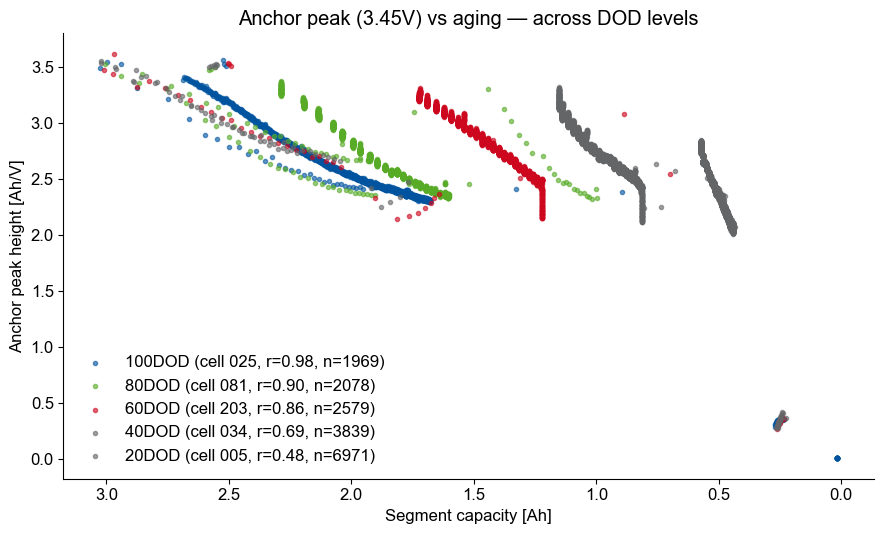

In [ ]:
# ================================================================
# 多DOD对比: 每颗电池跑 峰高~容量 追踪, 汇总
# CELLS 按上一格侦察结果填: {'100DOD':'025', '60DOD':'0xx', '40DOD':'0xx', ...}
# ================================================================
CELLS={'100DOD':'025', '80DOD':'081', '60DOD':'203', '40DOD':'034', '20DOD':'005'}
PEAK_BAND=(3.35,3.55)           # 锚点峰区间(3.45V石墨峰)

def life_curves(cid, dod_label):
    base=f"{VTC}/METABatt_Sony_Murata_18650VTC6_{cid}"
    files=[f for f in sorted(fs.ls(base)) if f.endswith('.parquet')]
    out=[]
    for f in files:
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
        d['Zeit']=TS(d['Zeit'])
        I=d['Strom'].values
        m=I<-1.0
        diff=np.diff(m.astype(int))
        st=np.where(diff==1)[0]+1; en=np.where(diff==-1)[0]+1
        if m[0]: st=np.r_[0,st]
        if m[-1]: en=np.r_[en,len(d)]
        for s,e in zip(st,en):
            if e-s<MIN_SEG: continue
            seg=d.iloc[s:e]; V=seg['Spannung'].values
            i0=np.argmax(V<V[0]-0.015)
            if i0>0 and e-s-i0>=MIN_SEG: seg=seg.iloc[i0:]; V=seg['Spannung'].values
            t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
            Q=np.cumsum(np.abs(seg['Strom'].values)*np.diff(t,prepend=t[0])/3600.0)
            o=np.argsort(V); Vu,idx=np.unique(V[o],return_index=True); Qu=Q[o][idx]
            vgrid=np.arange(Vu.min()+0.01,Vu.max()-0.01,DV_GRID)
            if len(vgrid)<50: continue
            Qsm=gaussian_filter1d(np.interp(vgrid,Vu,Qu),sigma=SIGMA)
            IC=np.abs(np.gradient(Qsm,vgrid))
            pm=(vgrid>=PEAK_BAND[0])&(vgrid<=PEAK_BAND[1])
            if pm.sum()<5: continue                       # 段没覆盖峰区→跳过
            out.append((Q[-1], IC[pm].max(), seg['Zeit'].iloc[0]))
    return out

fig,ax=plt.subplots(figsize=(9,5.5))
colors={'100DOD':'#00549F','80DOD':'#57AB27','60DOD':'#CC071E','40DOD':'#646567','20DOD':'#646567'}
for lbl,cid in CELLS.items():
    pts=life_curves(cid,lbl)
    if not pts: print(f"{lbl} cell {cid}: 无有效段(峰区未覆盖?)"); continue
    q=np.array([p[0] for p in pts]); h=np.array([p[1] for p in pts])
    r=np.corrcoef(q,h)[0,1] if len(q)>10 else np.nan
    ax.scatter(q,h,s=9,alpha=0.6,color=colors.get(lbl,'k'),
               label=f"{lbl} (cell {cid}, r={r:.2f}, n={len(q)})")
    print(f"{lbl} cell {cid}: {len(q)}段, 容量{q.min():.2f}~{q.max():.2f}Ah, r={r:.3f}")
ax.set_xlabel('Segment capacity [Ah]'); ax.set_ylabel('Anchor peak height [Ah/V]')
ax.set_title('Anchor peak (3.45V) vs aging — across DOD levels')
ax.legend(frameon=False); ax.invert_xaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('nca_dod_comparison.png',dpi=200,bbox_inches='tight')
plt.show()

In [7]:
# ---- 对每档: 按段容量分组重算r ----
# aging段: 容量在 [0.7, 1.3]×DOD名义容量 内; CU段: >2.5Ah
NOM = {'100DOD':3.0,'80DOD':2.4,'60DOD':1.8,'40DOD':1.2,'20DOD':0.6}
for lbl,cid in CELLS.items():
    pts=life_curves(cid,lbl)                # 或复用已存的pts
    q=np.array([p[0] for p in pts]); h=np.array([p[1] for p in pts])
    nom=NOM[lbl]
    m_aging=(q>0.7*nom)&(q<1.3*nom) if lbl!='100DOD' else q>2.0
    m_cu=q>2.5
    for tag,mm in [('aging段',m_aging),('CU满放',m_cu)]:
        if mm.sum()>30:
            # aging段内部没有容量作老化坐标 → 用时间序作代理: 段的先后顺序
            # 简化: 直接看 h 随样本序的趋势
            order=np.arange(mm.sum())
            r=np.corrcoef(order,h[mm][np.argsort(-q[mm]) if tag=='CU满放' else slice(None)])[0,1] \
              if tag=='CU满放' else np.corrcoef(order,h[mm])[0,1]
            print(f"{lbl} {tag}: n={mm.sum()}, r(峰高~时间序)={r:.3f}")

100DOD aging段: n=797, r(峰高~时间序)=-0.954
100DOD CU满放: n=92, r(峰高~时间序)=-0.477
80DOD aging段: n=1605, r(峰高~时间序)=-0.949
60DOD aging段: n=2201, r(峰高~时间序)=-0.994
40DOD aging段: n=3315, r(峰高~时间序)=-0.960
20DOD aging段: n=6926, r(峰高~时间序)=-0.980


In [8]:
# ---- 侦察: VTC capacity CSV 的结构 ----
CAP_VTC="projects/j8005-metabatt/Metabatt/VTC/40_capacity_monitore"
cfiles=fs.ls(CAP_VTC)
print(len(cfiles),"files, 示例:",cfiles[:3])

cap=pd.read_csv(f"s3://{CAP_VTC}/METABatt_Sony_Murata_18650VTC6_025_capacity.csv",
                storage_options=OPTS)          # 文件名格式若不同,按上面打印修正
print(cap.columns.tolist())
print(cap[['SOH','CAP_start_time']].dropna().head() if 'SOH' in cap.columns else cap.head())

409 files, 示例: ['projects/j8005-metabatt/Metabatt/VTC/40_capacity_monitore/METABatt_Sony_Murata_18650VTC6_003_capacity.csv', 'projects/j8005-metabatt/Metabatt/VTC/40_capacity_monitore/METABatt_Sony_Murata_18650VTC6_004_capacity.csv', 'projects/j8005-metabatt/Metabatt/VTC/40_capacity_monitore/METABatt_Sony_Murata_18650VTC6_005_capacity.csv']
['BM_Programm', 'Capacity_py', 'Ah_throughput', 'SOH', 'CAP_start_time']
    SOH                    CAP_start_time
0  95.8  2024-09-03 14:41:16.770000+00:00
1  91.6  2024-09-24 11:56:30.700000+00:00
2  88.8  2024-10-21 15:52:18.150000+00:00
3  86.6  2024-11-06 11:06:43.950000+00:00
4  84.9  2024-11-26 15:32:22.820000+00:00


In [13]:
# ---- 终审: 峰高 vs 官方SOH标签 ----
pts=life_curves(cid,lbl)
assert hasattr(pd.Timestamp(pts[0][2]),'year') and pd.Timestamp(pts[0][2]).year>2020, \
       f"第3元素不是时间戳: {pts[0][2]!r}"
def soh_interp_fn(cid):
    cap=pd.read_csv(f"s3://{CAP_VTC}/METABatt_Sony_Murata_18650VTC6_{cid}_capacity.csv",
                    storage_options=OPTS)
    s=cap.dropna(subset=['SOH']).copy()
    s['t']=TS(s['CAP_start_time']); s=s.sort_values('t')
    st=s['t'].values.astype('datetime64[s]').astype(np.float64)
    return lambda tsec: np.interp(tsec, st, s['SOH'].values), s['SOH'].min(), s['SOH'].max()

NOM={'100DOD':3.0,'80DOD':2.4,'60DOD':1.8,'40DOD':1.2,'20DOD':0.6}
for lbl,cid in CELLS.items():
    pts=life_curves(cid,lbl)                       # 需返回(容量,峰高,起始时间)版本
    q=np.array([p[0] for p in pts]); h=np.array([p[1] for p in pts])
    ts=np.array([pd.Timestamp(p[2]).value//10**9 for p in pts],dtype=float)
    f,slo,shi=soh_interp_fn(cid)
    nom=NOM[lbl]
    m=(q>0.7*nom)&(q<1.3*nom) if lbl!='100DOD' else q>2.0   # 只看aging段
    soh=f(ts[m])
    r=np.corrcoef(soh,h[m])[0,1]
    print(f"{lbl} cell {cid}: n={m.sum()}, r(峰高~SOH)={r:.3f}, 官方SOH {slo:.0f}~{shi:.0f}%")

100DOD cell 025: n=797, r(峰高~SOH)=0.977, 官方SOH 65~96%
80DOD cell 081: n=1605, r(峰高~SOH)=0.975, 官方SOH 64~96%
60DOD cell 203: n=2201, r(峰高~SOH)=0.996, 官方SOH 55~96%
40DOD cell 034: n=3315, r(峰高~SOH)=0.977, 官方SOH 59~96%
20DOD cell 005: n=6926, r(峰高~SOH)=0.993, 官方SOH 74~96%


In [14]:
def life_curves(cid, lbl):
    base=f"{VTC}/METABatt_Sony_Murata_18650VTC6_{cid}"
    files=[f for f in sorted(fs.ls(base)) if f.endswith('.parquet')]
    out=[]
    for f in files:
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
        d['Zeit']=TS(d['Zeit'])
        I=d['Strom'].values
        m=I<-1.0
        diff=np.diff(m.astype(int))
        st=np.where(diff==1)[0]+1; en=np.where(diff==-1)[0]+1
        if m[0]: st=np.r_[0,st]
        if m[-1]: en=np.r_[en,len(d)]
        for s,e in zip(st,en):
            if e-s<MIN_SEG: continue
            seg=d.iloc[s:e]; V=seg['Spannung'].values
            i0=np.argmax(V<V[0]-0.015)
            if i0>0 and e-s-i0>=MIN_SEG:
                seg=seg.iloc[i0:]; V=seg['Spannung'].values
            t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
            Q=np.cumsum(np.abs(seg['Strom'].values)*np.diff(t,prepend=t[0])/3600.0)
            o=np.argsort(V); Vu,idx=np.unique(V[o],return_index=True); Qu=Q[o][idx]
            vgrid=np.arange(Vu.min()+0.01,Vu.max()-0.01,DV_GRID)
            if len(vgrid)<30: continue
            Qsm=gaussian_filter1d(np.interp(vgrid,Vu,Qu),sigma=SIGMA)
            IC=np.abs(np.gradient(Qsm,vgrid))
            pm=(vgrid>=3.35)&(vgrid<=3.55)
            if pm.sum()<5: continue
            out.append((Q[-1], IC[pm].max(), seg['Zeit'].iloc[0]))   # ← 时间戳在第3位
    return out